Source:
- https://colab.research.google.com/github/EdjeElectronics/Train-and-Deploy-YOLO-Models/blob/main/Train_YOLO_Models.ipynb#scrollTo=8X62eFTugosf

In [8]:
import cv2
print(cv2.__version__)

4.13.0


In [ ]:
# check NVIDIA GPU devices
!nvidia-smi

Sat Mar  7 16:51:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.80                 Driver Version: 581.80         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   51C    P3             24W /   80W |    1175MiB /   6144MiB |     24%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

A Python script is written to automatically create the required folder structure and randomly move 90% of dataset to the "train" folder and 10% to the "validation" folder.

For simplicity and learning sake, the python file will be replicated in this repo.

In [ ]:
# split to train and validation folders
!python train_val_split.py --datapath="C:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\labeled_data" --train_pct=0.9


Created folder at c:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\split_data/train/images.
Created folder at c:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\split_data/train/labels.
Created folder at c:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\split_data/validation/images.
Created folder at c:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\split_data/validation/labels.
Number of image files: 68
Number of annotation files: 68
Images moving to train: 61
Images moving to validation: 7


ultralytics library will be used to train the model
Using YOLO Model (You Only Look Once) 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.4.0+cpu requires torch==2.4.0, but you have torch 2.10.0 which is incompatible.

*The error above to keep in mind when training. This can result in lib conflict

Hence, its best to use another environment with Anaconda for this purpose

In [ ]:
# pip install ultralytics

Before training using Ultralytics, we need to create a configuration YAML file. 
This file specifies the location of train and validation data. It also defines the model's classes

the code below automatically generates a data.yaml config file using the path to the split_data

In [ ]:
# Python function to automatically create data.yaml config file
# 1. Reads "classes.txt" file to get list of class names
# 2. Creates data dictionary with correct paths to folders, number of classes, and names of classes
# 3. Writes data in YAML format to data.yaml

import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read class.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Create data dictionary for the pathing
  data = {
      'path': r'C:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\split_data',
      'train': r'C:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\split_data\train\images',
      'val': r'C:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\split_data\validation\images',
      'nc': number_of_classes,
      'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Define path to classes.txt and run function
path_to_classes_txt = r'C:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\labeled_data\classes.txt'
path_to_data_yaml = r'C:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')

Created config file at C:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\data.yaml

File contents:



'cat' is not recognized as an internal or external command,
operable program or batch file.


Train the model using the config file. 

With YOLO11 model, it comes with different sizes such as yolo11n.pt, yolo11s.pt, yolo11m.pt, yolo11l.pt, and yolo11xl.pt.

Large models run slower but have higher accuracy
Small models run faster but have lower accuracy
Small models are a good starting point

YOLOv8 and YOLOv5 are also usable, yolov8 or yolov5

Training images, the best amount of epoch to use depends on size of dataset and model architecture

- if less than 200 images, a good starting point is 60 epochs
- if more than 200 images, a good starting point is 40 epochs

Resolution (imgsz)
- It has a big impact on the speed and accuracy of the model. 
- Lower resolution model will have higher speed but less accuracy 
- YOLO models are typically trained and inferenced  at a 640*640 resolution.
- But to run faster or working with low-resolution images, try using 480*480 resolution



In [1]:
!yolo detect train data="C:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\data.yaml" model=yolo11s.pt epochs=60 imgsz=640

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\limsi\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Ultralytics 8.4.21  Python-3.10.7 torch-2.10.0+cpu CPU (12th Gen Intel Core i7-12700H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, free

Best trained model is stored in runs/train/weights/best.pt

Additional information about training is saved in runs/detect/train

It includes a results.png file that shows loss, precision, recall, can mAP (IOU) progression over each epoch

Test Model using the code below. Display the result for the first 10 images.

A good way to confirm the model is working as expected

In [2]:
!yolo detect predict model="C:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\runs\detect\train\weights\best.pt" source="C:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\split_data\validation\images" save=True

Ultralytics 8.4.21  Python-3.10.7 torch-2.10.0+cpu CPU (12th Gen Intel Core i7-12700H)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

image 1/7 C:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\split_data\validation\images\05e40a7d-301.jpg: 480x640 1 nametag, 122.7ms
image 2/7 C:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\split_data\validation\images\18448c0b-388.jpg: 480x640 1 nametag, 103.8ms
image 3/7 C:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\split_data\validation\images\40a79430-373.jpg: 480x640 1 nametag, 99.4ms
image 4/7 C:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\split_data\validation\images\87a1e210-310.jpg: 480x640 1 nametag, 102.6ms
image 5/7 C:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\split_data\validation\images\a1e9d362-308.jpg: 480x640 (no detections), 100.0ms
image 6/7 C:\Users\limsi\OneDrive\Desktop\NameTag Identifi

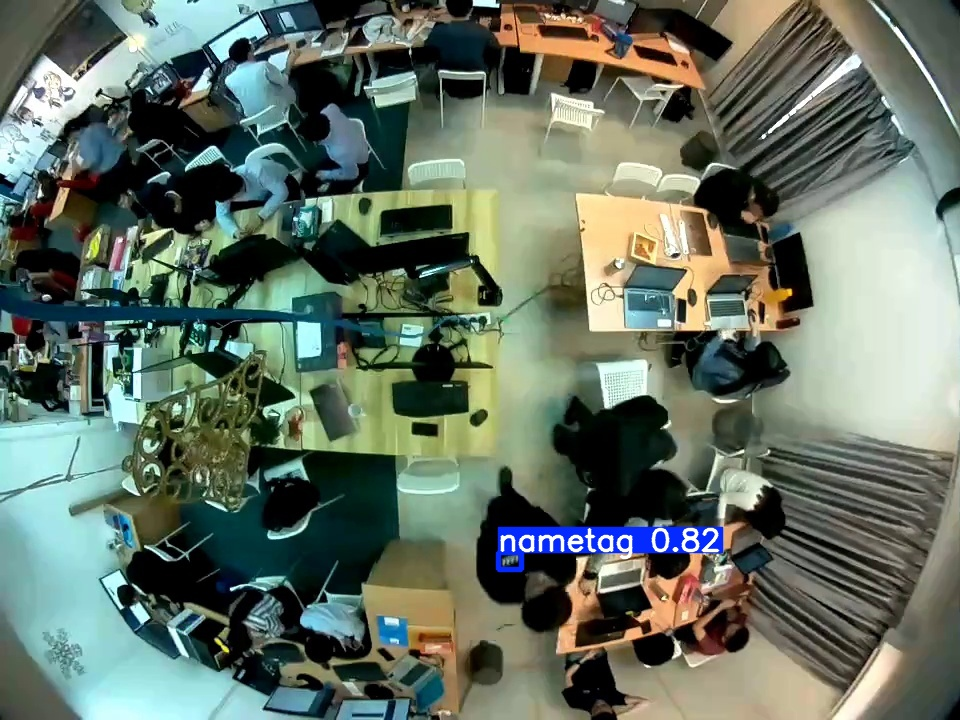

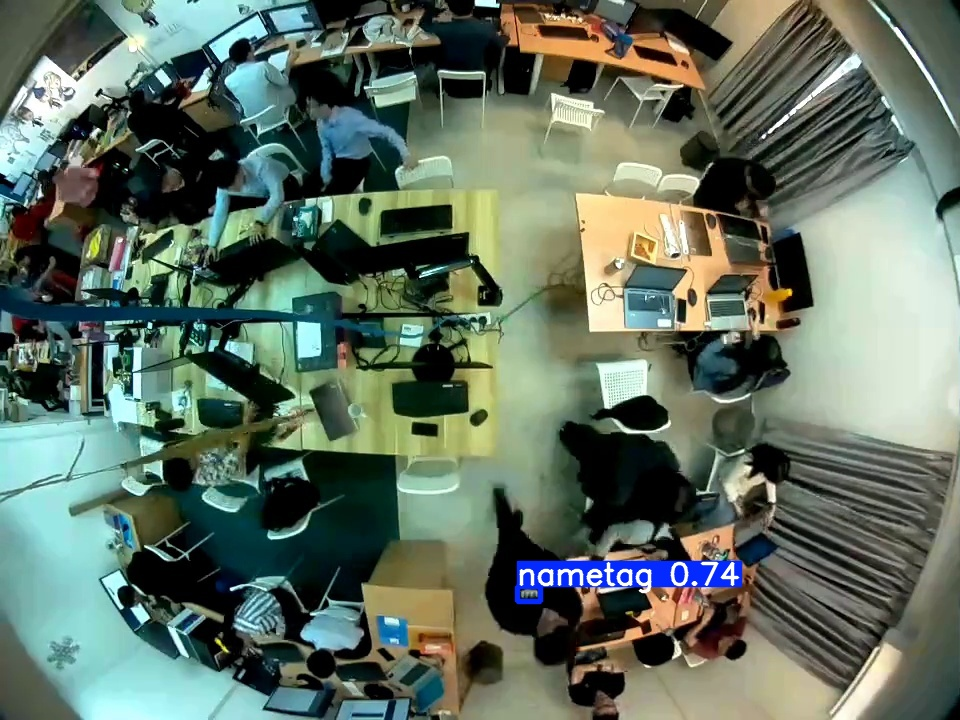

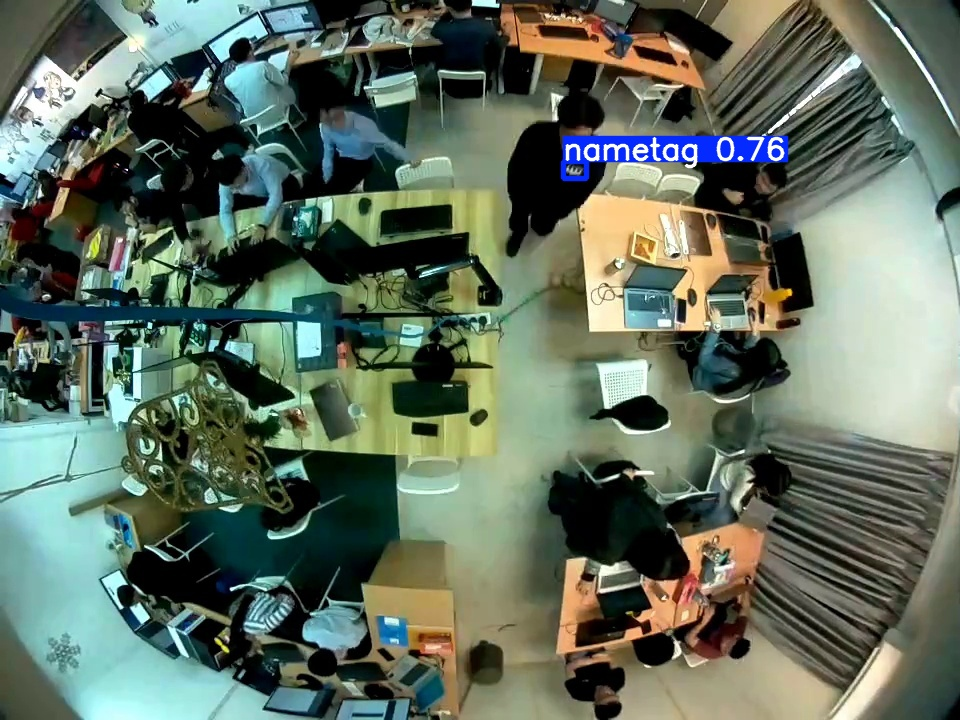

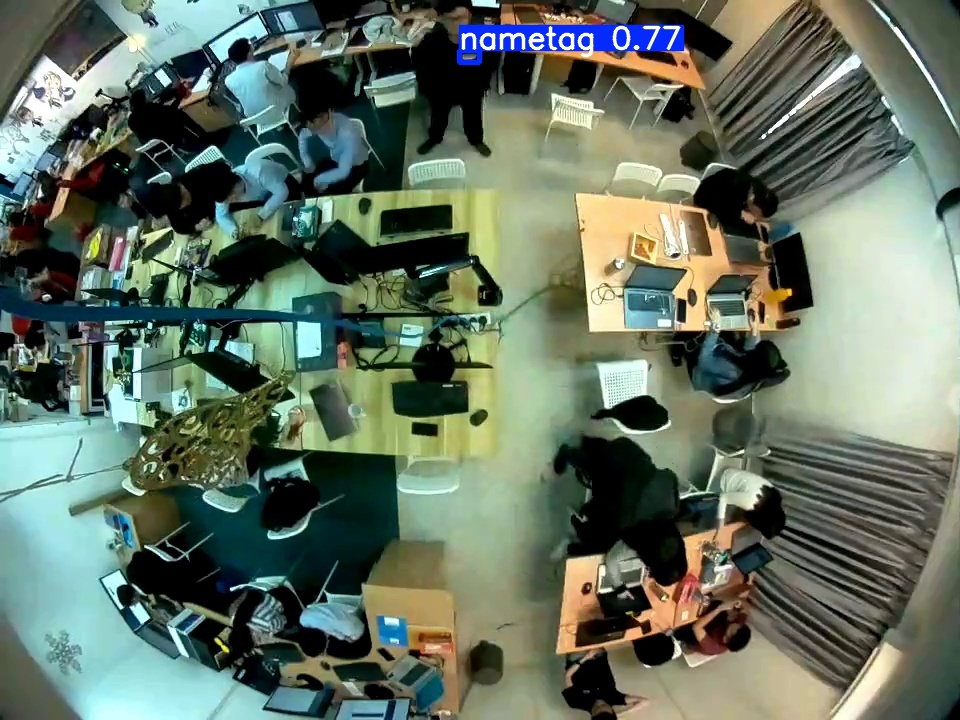

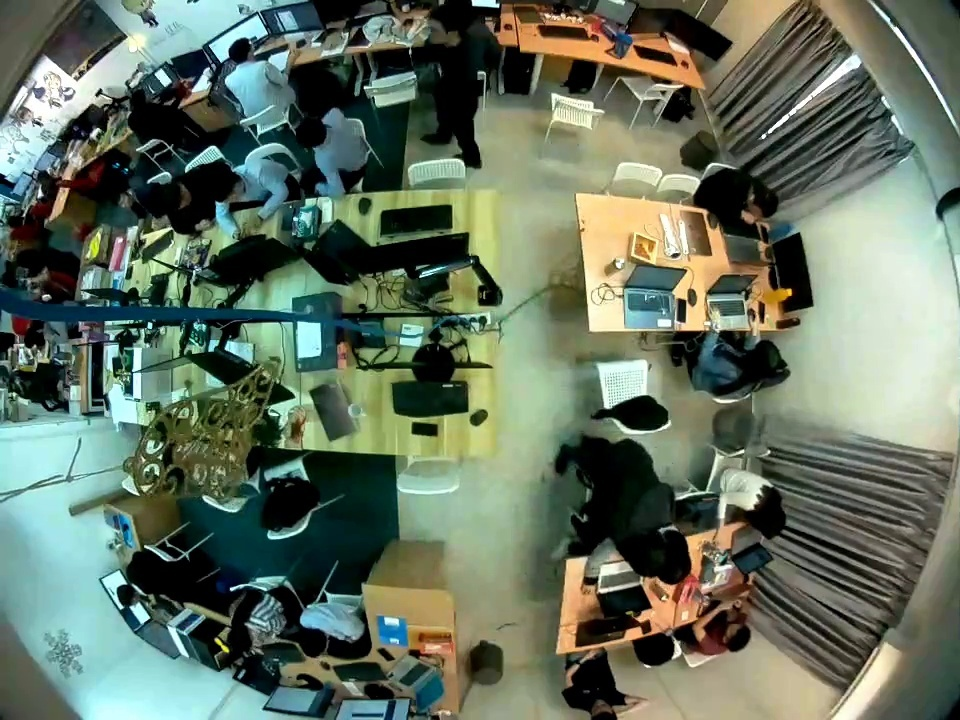

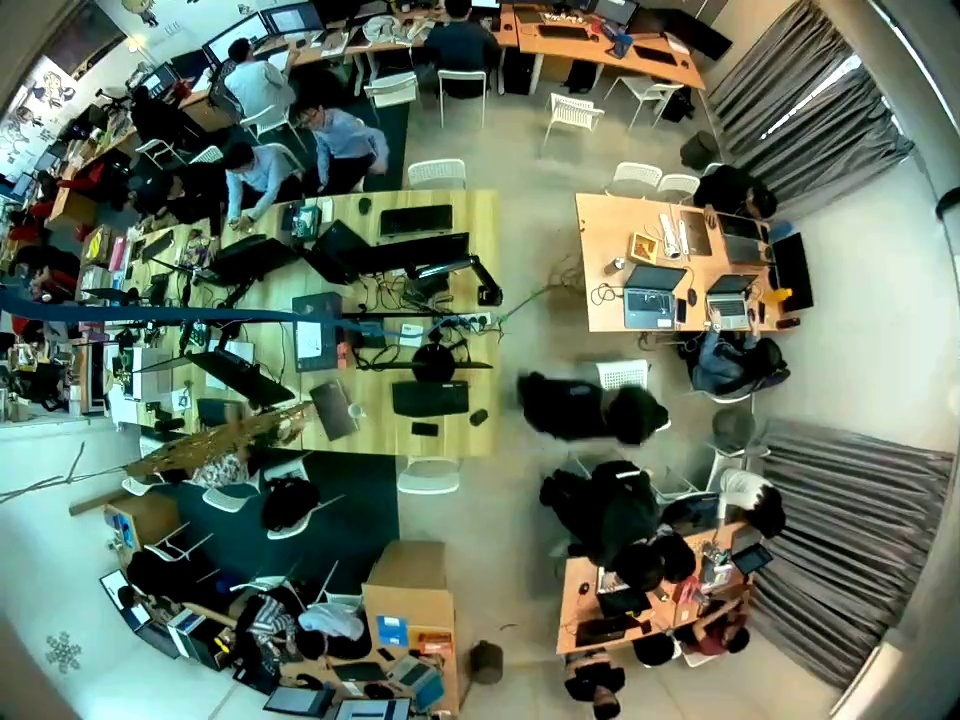

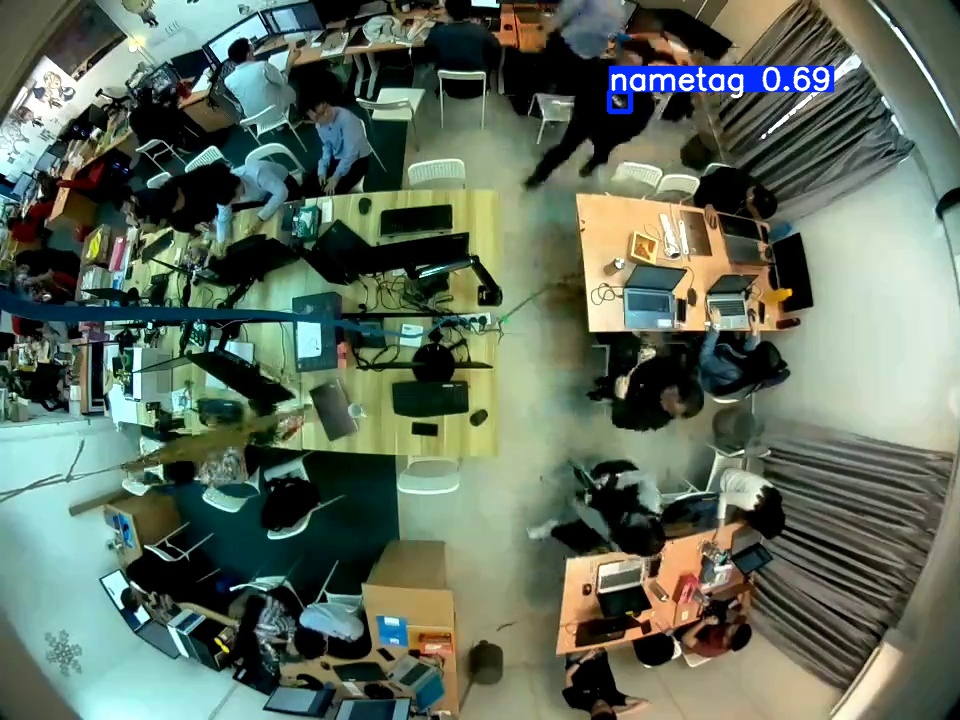

In [4]:
import glob 

from IPython.display import Image, display
for image_path in glob.glob(r"C:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\runs\detect\predict/*.jpg")[:10]:
    display(Image(filename=image_path, height=400))
    print('\n')

The model should draw a box around each object of interest in each image. If it isn't doing a good job in detecting intended objects, here are a few tips:

1. double-check your dataset to make sure there are no labeling errors or conflicting examples
2. increase the number of epochs used for training
3. use a larger model size
4. Add more images to the training dataset.

You can also run the model on video files or other images by uploading them to the notebook using this `!yolo detect predict` command, where `source` points to the location of the video. Results will be saved in `runs/detect/predict`

Drawing boxes on images is great, but it isn't very useful in itself and running it on a Colab Notebook isnt either. Running it on a local computer is easier

Now the model has been trained, it can be downloaded and deployed in an application.

YOLO can be run on a wide variety of hardware such as PCs, embedded systesm, and phones. Ultralytics makes it easy to convert the YOLO models to various formats such as `tflite, onnx` and deply them into environments



In [ ]:
# Download YOLO model, refine it later

# Create "your_model" folder to store model weights and train results
# in my case, i moved them manually, but the code below can be used if you have the path

!mkdir "path"
!cp "path" "path"
!cp -r "path" "path"

# Zip into "nametag_model.zip"
%cd nametag_model
!zip "path" nametag_model.pt
!zip -r "path" train
%cd /content

A subdirectory or file C:/Users/limsi/OneDrive/Desktop/NameTag Identification Video Project/nametag_model already exists.
'cp' is not recognized as an internal or external command,
operable program or batch file.


[WinError 2] The system cannot find the file specified: 'nametag_model'
c:\Users\limsi\OneDrive\Desktop\NameTag Identification Video Project\nametag_model


'cp' is not recognized as an internal or external command,
operable program or batch file.
'zip' is not recognized as an internal or external command,
operable program or batch file.
'zip' is not recognized as an internal or external command,
operable program or batch file.


# Deploy YOLO Model on Local Devices

A modified yolo_detect.py shows how to load a model, run inference on an image source, parse the inference results, and display boxes around each detected class in the image for this project. 

The script gives an example of how to work with Ultralytics YOLO models in Python, and it can be used as a starting point for more advanced applications. (cited in the given source)

In [ ]:
%run yolo_detect.py
# there seems to be a library conflict in env, use anaconda env to run it